# Fetal Head Clinical AI — Phase 2: Temporal Attention System
**Author:** Tarun Sadarla  
**Depends on:**
- Phase 0 backbone: `checkpoints/phase0/best_model.pth` (Dice 97.36%, MAE 1.75mm)
- Phase 1 cine dataset: `cine_dataset/` (806 clips, 16 frames, Stage 4)

## Architecture
```
Input: [B, T, 1, H, W]  — batch of T=16 frame clips
  ↓
Shared 2D Residual U-Net encoder  (frozen Phase 0 backbone weights)
  → bottleneck features per frame: [B, T, C, h, w]
  ↓
Temporal Self-Attention module
  → attends across T dimension: which frames are most reliable?
  → returns temporally-refined bottleneck: [B, T, C, h, w]
  ↓
Shared 2D U-Net decoder  (fine-tuned end-to-end)
  → per-frame segmentation logits: [B, T, 1, H, W]
  ↓
Temporal aggregation  → clip-level consensus mask
  ↓
Ellipse fitting → HC (mm) → GA (weeks)
```

## Training strategy (3 stages)
1. **Frozen backbone** — train attention module only (5 epochs, fast)
2. **Partial unfreeze** — unfreeze decoder, keep encoder frozen (10 epochs)
3. **Full fine-tune** — all weights, low LR (remaining epochs)

## Ablation study (publishable contribution)
We compare three configurations to isolate the temporal attention contribution:
- **A** Static baseline only (Phase 0, no temporal)
- **B** 2D U-Net on cine frames independently (no attention)
- **C** 2D U-Net + temporal attention (full system)

The key result: C > B > A on MAE demonstrates that (1) cine data helps even
without temporal modeling, and (2) attention adds further gain on top.

## 0. Setup

In [1]:
!pip install albumentations==1.4.0 --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.6/123.6 kB 3.0 MB/s eta 0:00:00


In [2]:
import os, json, random, shutil
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from skimage.measure import label, regionprops

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [3]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR   = Path('/content/drive/MyDrive/fetal_head_clinical_ai')
PHASE0_CKPT   = PROJECT_DIR / 'checkpoints' / 'phase0' / 'best_model.pth'
CINE_DIR      = PROJECT_DIR / 'cine_dataset'
CKPT_DIR      = PROJECT_DIR / 'checkpoints' / 'phase2'
RESULTS_DIR   = PROJECT_DIR / 'results' / 'phase2'

CKPT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

assert PHASE0_CKPT.exists(), 'Phase 0 checkpoint missing'
assert (CINE_DIR / 'metadata.csv').exists(), 'Phase 1 cine dataset missing'
print('Phase 0 checkpoint: OK')
print('Phase 1 cine dataset: OK')

# Config
INPUT_H, INPUT_W = 256, 384
N_FRAMES         = 16
BATCH_SIZE       = 4    # each sample is 16 frames — fits on T4 at batch=4
NUM_WORKERS      = 2

Mounted at /content/drive
Phase 0 checkpoint: OK
Phase 1 cine dataset: OK


## 1. Cine dataset loader

In [4]:
# Load metadata and pixel spacing
df_meta = pd.read_csv(CINE_DIR / 'metadata.csv')
print(f'Total clips: {len(df_meta)}')
print(df_meta.head(3))

train_df = df_meta[df_meta['split'] == 'train'].reset_index(drop=True)
val_df   = df_meta[df_meta['split'] == 'val'].reset_index(drop=True)
test_df  = df_meta[df_meta['split'] == 'test'].reset_index(drop=True)
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

Total clips: 806
     stem  split                           clip_path  pixel_spacing  hc_gt_mm  \
0  284_HC  train  cine_dataset/train/284_HC_clip.npz       0.129572    167.73   
1  606_HC  train  cine_dataset/train/606_HC_clip.npz       0.238967    186.20   
2  269_HC  train  cine_dataset/train/269_HC_clip.npz       0.130278    174.80   

   n_frames  stage  
0        16      4  
1        16      4  
2        16      4  
Train: 564 | Val: 121 | Test: 121


In [6]:
class CineDataset(Dataset):
    """
    Loads pre-generated cine clips from Phase 1.

    Returns:
        frames:        [T, 1, H, W] float32 tensor, normalised ~N(0,1)
        masks:         [T, 1, H, W] float32 tensor, binary {0,1}
        pixel_spacing: scalar float (mm/pixel at original resolution)
        hc_gt_mm:      scalar float (ground truth HC in mm)
        stem:          filename stem for identification
    """
    # ImageNet-style normalisation parameters estimated from HC18
    # (grayscale US: mean ~0.2, std ~0.15 after /255)
    IMG_MEAN = 0.2
    IMG_STD  = 0.15

    def __init__(self, df, cine_dir, augment=False):
        self.df       = df
        self.cine_dir = Path(cine_dir)
        self.augment  = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        npz_path = PROJECT_DIR / row['clip_path']

        clip = np.load(str(npz_path))
        frames = clip['frames'].astype(np.float32)  # [T, H, W]
        masks  = clip['masks'].astype(np.float32)   # [T, H, W]

        # Normalise frames: (x - mean) / std
        frames = (frames - self.IMG_MEAN) / (self.IMG_STD + 1e-8)

        # Light temporal augmentation during training:
        # Randomly reverse the clip (probe moving in opposite direction)
        if self.augment and random.random() < 0.5:
            frames = frames[::-1].copy()
            masks  = masks[::-1].copy()

        # [T, H, W] → [T, 1, H, W]
        frames = torch.from_numpy(frames).unsqueeze(1)
        masks  = torch.from_numpy(masks).unsqueeze(1)

        pixel_spacing = float(row['pixel_spacing']) if pd.notna(row['pixel_spacing']) else 0.1
        hc_gt_mm      = float(row['hc_gt_mm'])      if pd.notna(row['hc_gt_mm'])      else 0.0
        stem          = str(row['stem'])

        return frames, masks, pixel_spacing, hc_gt_mm, stem


train_dataset = CineDataset(train_df, CINE_DIR, augment=True)
val_dataset   = CineDataset(val_df,   CINE_DIR, augment=False)
test_dataset  = CineDataset(test_df,  CINE_DIR, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

# Shape check
frames_b, masks_b, ps_b, hc_b, stems_b = next(iter(train_loader))
print(f'Frames batch: {frames_b.shape}   dtype: {frames_b.dtype}')
print(f'Masks  batch: {masks_b.shape}    dtype: {masks_b.dtype}')
print(f'Pixel spacing sample: {ps_b[0].item():.5f} mm/px')
print(f'HC GT sample: {hc_b[0].item():.2f} mm')

Frames batch: torch.Size([4, 16, 1, 256, 384])   dtype: torch.float32
Masks  batch: torch.Size([4, 16, 1, 256, 384])    dtype: torch.float32
Pixel spacing sample: 0.12308 mm/px
HC GT sample: 180.78 mm


## 2. Phase 0 backbone — restore architecture

Exact same ResidualUNetDS class from Phase 0. We load the pretrained weights
then surgically extract the encoder and decoder as separate modules for
the temporal architecture.

In [7]:
class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.BatchNorm2d(in_ch), nn.ReLU(inplace=True),
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
        )
        self.skip = nn.Conv2d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        return self.block(x) + self.skip(x)


class ResidualUNetDS(nn.Module):
    """Phase 0 backbone — kept identical for weight loading."""
    def __init__(self, in_ch=1, base_ch=32):
        super().__init__()
        b = base_ch
        self.enc1 = ResidualBlock(in_ch, b)
        self.enc2 = ResidualBlock(b,   b*2)
        self.enc3 = ResidualBlock(b*2, b*4)
        self.enc4 = ResidualBlock(b*4, b*8)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = ResidualBlock(b*8, b*16)
        self.up4  = nn.ConvTranspose2d(b*16, b*8, 2, stride=2)
        self.dec4 = ResidualBlock(b*16, b*8)
        self.up3  = nn.ConvTranspose2d(b*8,  b*4, 2, stride=2)
        self.dec3 = ResidualBlock(b*8,  b*4)
        self.up2  = nn.ConvTranspose2d(b*4,  b*2, 2, stride=2)
        self.dec2 = ResidualBlock(b*4,  b*2)
        self.up1  = nn.ConvTranspose2d(b*2,  b,   2, stride=2)
        self.dec1 = ResidualBlock(b*2,  b)
        self.final  = nn.Conv2d(b, 1, 1)
        self.aux_d3 = nn.Conv2d(b*4, 1, 1)
        self.aux_d2 = nn.Conv2d(b*2, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        bn = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(bn), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        main = self.final(d1)
        if self.training:
            aux3 = torch.sigmoid(F.interpolate(self.aux_d3(d3), size=x.shape[2:], mode='bilinear', align_corners=False))
            aux2 = torch.sigmoid(F.interpolate(self.aux_d2(d2), size=x.shape[2:], mode='bilinear', align_corners=False))
            return main, aux3, aux2
        return main

    def encode(self, x):
        """Encoder only — returns (bottleneck, skip_connections)."""
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        bn = self.bottleneck(self.pool(e4))
        return bn, (e1, e2, e3, e4)

    def decode(self, bn, skips):
        """Decoder only — takes attended bottleneck + original skip connections."""
        e1, e2, e3, e4 = skips
        d4 = self.dec4(torch.cat([self.up4(bn), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.final(d1)


# Load Phase 0 weights
backbone = ResidualUNetDS(in_ch=1, base_ch=32)
ckpt = torch.load(str(PHASE0_CKPT), map_location='cpu')
backbone.load_state_dict(ckpt['model_state_dict'])
print(f'Phase 0 backbone loaded (epoch {ckpt["epoch"]}, val Dice {ckpt["val_dice"]*100:.2f}%)')
print(f'Backbone parameters: {sum(p.numel() for p in backbone.parameters()):,}')

Phase 0 backbone loaded (epoch 70, val Dice 97.50%)
Backbone parameters: 8,110,789


## 3. Temporal Self-Attention module

**Design:** Multi-head self-attention over the T (time) dimension of bottleneck features.

**How it works:**
1. The encoder produces bottleneck features of shape `[B, C, h, w]` per frame
   where C=512, h=H/16=16, w=W/16=24 for our input size.
2. We spatially pool each frame's features to a single vector: `[B, C]`
3. Stack T frames → `[B, T, C]`
4. Add learnable positional encoding for frame order
5. Apply multi-head self-attention across T: each frame can attend to all other frames
6. The model learns: 'frame 3 has a clear skull boundary, weight it higher'
7. Attended features are used to modulate the bottleneck before decoding

**Why this is lightweight:** Attention operates on pooled C-dimensional vectors,
not on the full spatial feature maps. Total attention parameters: ~200K vs
the backbone's 32M. Memory overhead is negligible.

In [8]:
class TemporalAttentionModule(nn.Module):
    """
    Lightweight temporal self-attention over a sequence of bottleneck feature maps.

    Operates on spatially-pooled bottleneck vectors to keep memory minimal.
    Produces per-frame attention weights that modulate the bottleneck features.

    Args:
        bottleneck_ch: number of channels in backbone bottleneck (512 for base_ch=32)
        n_frames:      sequence length T
        n_heads:       number of attention heads (must divide bottleneck_ch)
        dropout:       attention dropout for regularisation
    """
    def __init__(self, bottleneck_ch=512, n_frames=16, n_heads=8, dropout=0.1):
        super().__init__()
        self.bottleneck_ch = bottleneck_ch
        self.n_frames = n_frames

        # Project bottleneck to attention dimension (smaller for efficiency)
        self.attn_dim = 256
        self.proj_in  = nn.Linear(bottleneck_ch, self.attn_dim)

        # Learnable positional encoding for frame order
        # (tells the model that frame 3 comes after frame 2)
        self.pos_encoding = nn.Parameter(torch.randn(1, n_frames, self.attn_dim) * 0.02)

        # Multi-head self-attention
        self.attn = nn.MultiheadAttention(
            embed_dim=self.attn_dim,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True   # [B, T, C] convention
        )
        self.norm1 = nn.LayerNorm(self.attn_dim)

        # Feed-forward refinement (standard Transformer block)
        self.ff = nn.Sequential(
            nn.Linear(self.attn_dim, self.attn_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(self.attn_dim * 2, self.attn_dim),
        )
        self.norm2 = nn.LayerNorm(self.attn_dim)

        # Project back and produce spatial modulation weights
        # Output: per-frame spatial attention map that scales the bottleneck
        self.proj_out = nn.Sequential(
            nn.Linear(self.attn_dim, bottleneck_ch),
            nn.Sigmoid()   # weights in [0,1] — multiplicative modulation
        )

        self._init_weights()

    def _init_weights(self):
        # Initialise proj_out bias to 1 so early training is near-identity
        # (attention starts neutral, gradually learns to reweight frames)
        nn.init.constant_(self.proj_out[0].bias, 1.0)

    def forward(self, bottleneck_seq):
        """
        Args:
            bottleneck_seq: [B, T, C, h, w] — sequence of bottleneck feature maps

        Returns:
            attended_seq:   [B, T, C, h, w] — modulated bottleneck features
            attn_weights:   [B, T, T] — attention weight matrix (for visualisation)
        """
        B, T, C, h, w = bottleneck_seq.shape

        # Spatial average pooling: [B, T, C, h, w] → [B, T, C]
        pooled = bottleneck_seq.mean(dim=(-2, -1))  # [B, T, C]

        # Project to attention dimension
        x = self.proj_in(pooled)  # [B, T, attn_dim]

        # Add positional encoding
        x = x + self.pos_encoding[:, :T, :]

        # Self-attention with residual
        attn_out, attn_weights = self.attn(x, x, x)
        x = self.norm1(x + attn_out)  # [B, T, attn_dim]

        # Feed-forward with residual
        x = self.norm2(x + self.ff(x))  # [B, T, attn_dim]

        # Project to per-frame spatial modulation weights
        mod_weights = self.proj_out(x)  # [B, T, C] in [0,1]

        # Apply modulation: expand to spatial dims and multiply
        mod_weights = mod_weights.unsqueeze(-1).unsqueeze(-1)  # [B, T, C, 1, 1]
        attended_seq = bottleneck_seq * mod_weights             # [B, T, C, h, w]

        return attended_seq, attn_weights


# Verify shapes
attn_module = TemporalAttentionModule(bottleneck_ch=512, n_frames=N_FRAMES, n_heads=8)
dummy_bn = torch.zeros(2, N_FRAMES, 512, 16, 24)  # [B=2, T=16, C=512, h=16, w=24]
out_bn, out_attn = attn_module(dummy_bn)
print(f'Attended bottleneck shape: {out_bn.shape}')    # should be [2, 16, 512, 16, 24]
print(f'Attention weights shape:   {out_attn.shape}')  # should be [2, 16, 16]
print(f'Attention module parameters: {sum(p.numel() for p in attn_module.parameters()):,}')

Attended bottleneck shape: torch.Size([2, 16, 512, 16, 24])
Attention weights shape:   torch.Size([2, 16, 16])
Attention module parameters: 794,112


## 4. Full temporal segmentation model

In [9]:
class TemporalFetaSegNet(nn.Module):
    """
    Full temporal segmentation system.

    Wraps the Phase 0 backbone with a temporal attention module.
    Processes a clip of T frames, applies attention across the bottleneck
    sequence, then decodes each frame using the attended features.

    Forward pass:
        Input:  [B, T, 1, H, W]
        Output: [B, T, 1, H, W]  per-frame segmentation logits
    """
    def __init__(self, backbone, attn_module):
        super().__init__()
        self.backbone = backbone
        self.attn     = attn_module

    def forward(self, clip):
        """
        Args:
            clip: [B, T, 1, H, W]
        Returns:
            logits: [B, T, 1, H, W]  — raw logits, sigmoid in loss
            attn_weights: [B, T, T]  — for visualisation/analysis
        """
        B, T, C, H, W = clip.shape

        # --- Encode all frames (shared weights) ---
        # Reshape to process all frames as one big batch through the encoder
        clip_flat = clip.view(B * T, C, H, W)             # [B*T, 1, H, W]
        bottlenecks, skips_flat = self.backbone.encode(clip_flat)
        # bottlenecks: [B*T, 512, h, w]
        # skips_flat: tuple of [B*T, c, h', w'] at each scale

        _, Cbn, hbn, wbn = bottlenecks.shape
        # Reshape to sequence: [B, T, 512, h, w]
        bn_seq = bottlenecks.view(B, T, Cbn, hbn, wbn)

        # --- Temporal attention ---
        bn_attended, attn_weights = self.attn(bn_seq)  # [B, T, 512, h, w]

        # Flatten back for decoding
        bn_attended_flat = bn_attended.view(B * T, Cbn, hbn, wbn)

        # --- Decode all frames ---
        logits_flat = self.backbone.decode(bn_attended_flat, skips_flat)  # [B*T, 1, H, W]
        logits = logits_flat.view(B, T, 1, H, W)

        return logits, attn_weights


# Assemble model
attn_module = TemporalAttentionModule(bottleneck_ch=512, n_frames=N_FRAMES, n_heads=8)
model = TemporalFetaSegNet(backbone, attn_module).to(DEVICE)

# Verify end-to-end shape
dummy_clip = torch.zeros(2, N_FRAMES, 1, INPUT_H, INPUT_W).to(DEVICE)
with torch.no_grad():
    logits_out, attn_out = model(dummy_clip)
print(f'Logits output shape:  {logits_out.shape}')  # [2, 16, 1, 256, 384]
print(f'Attn weights shape:   {attn_out.shape}')    # [2, 16, 16]

total_params     = sum(p.numel() for p in model.parameters())
attn_params      = sum(p.numel() for p in model.attn.parameters())
backbone_params  = sum(p.numel() for p in model.backbone.parameters())
print(f'\nParameter breakdown:')
print(f'  Backbone:  {backbone_params:>10,}')
print(f'  Attention: {attn_params:>10,}')
print(f'  Total:     {total_params:>10,}')

Logits output shape:  torch.Size([2, 16, 1, 256, 384])
Attn weights shape:   torch.Size([2, 16, 16])

Parameter breakdown:
  Backbone:   8,110,789
  Attention:    794,112
  Total:      8,904,901


## 5. Loss functions and training utilities

In [10]:
def dice_loss(pred_logits, target, smooth=1e-5):
    pred = torch.sigmoid(pred_logits)
    p, t = pred.view(-1), target.view(-1)
    inter = (p * t).sum()
    return 1 - (2 * inter + smooth) / (p.sum() + t.sum() + smooth)


def seg_loss(logits, masks):
    """Combined BCE+Dice over all T frames."""
    bce  = F.binary_cross_entropy_with_logits(logits, masks)
    dice = dice_loss(logits, masks)
    return 0.5 * bce + 0.5 * dice


def dice_score(pred_logits, target, smooth=1e-5):
    """Dice coefficient for monitoring (not backprop)."""
    pred = (torch.sigmoid(pred_logits) > 0.5).float()
    p, t = pred.view(-1), target.view(-1)
    inter = (p * t).sum()
    return ((2 * inter + smooth) / (p.sum() + t.sum() + smooth)).item()


def set_trainable(model, stage):
    """
    Control which parameters are trainable per training stage.

    Stage 1: attention module only (backbone fully frozen)
    Stage 2: attention + decoder (encoder still frozen)
    Stage 3: all parameters (full fine-tune, low LR)
    """
    # Freeze everything first
    for p in model.parameters():
        p.requires_grad = False

    if stage == 1:
        for p in model.attn.parameters():
            p.requires_grad = True
        label = 'attention only'

    elif stage == 2:
        for p in model.attn.parameters():
            p.requires_grad = True
        # Unfreeze decoder components
        for name in ['up4','dec4','up3','dec3','up2','dec2','up1','dec1','final','aux_d3','aux_d2']:
            for p in getattr(model.backbone, name).parameters():
                p.requires_grad = True
        label = 'attention + decoder'

    elif stage == 3:
        for p in model.parameters():
            p.requires_grad = True
        label = 'all parameters'

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Training stage {stage} ({label}): {trainable:,} trainable parameters')


def train_one_epoch(model, loader, optimizer, scaler, device):
    model.train()
    total_loss, total_dice = 0.0, 0.0

    for frames, masks, _, _, _ in loader:
        frames = frames.to(device)  # [B, T, 1, H, W]
        masks  = masks.to(device)

        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            logits, _ = model(frames)        # [B, T, 1, H, W]
            loss = seg_loss(logits, masks)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        with torch.no_grad():
            total_dice += dice_score(logits, masks)
        total_loss += loss.item()

    n = len(loader)
    return total_loss / n, total_dice / n


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss, total_dice = 0.0, 0.0
    for frames, masks, _, _, _ in loader:
        frames = frames.to(device)
        masks  = masks.to(device)
        with torch.amp.autocast('cuda'):
            logits, _ = model(frames)
            loss = seg_loss(logits, masks)
        total_dice += dice_score(logits, masks)
        total_loss += loss.item()
    n = len(loader)
    return total_loss / n, total_dice / n


print('Loss functions and training utilities defined.')

Loss functions and training utilities defined.


## 6. Three-stage training

In [11]:
history  = {'train_loss': [], 'train_dice': [], 'val_loss': [], 'val_dice': [], 'lr': [], 'stage': []}
scaler   = torch.cuda.amp.GradScaler()
best_val_dice = 0.0
BEST_CKPT = str(CKPT_DIR / 'best_model.pth')

STAGE_CONFIG = [
    # (stage_id, n_epochs, lr, patience)
    (1,  8,  3e-4, 5),   # attention only — fast convergence, high LR
    (2, 15,  1e-4, 8),   # attention + decoder — moderate LR
    (3, 30,  3e-5, 12),  # full fine-tune — low LR, long patience
]

global_epoch = 0

for stage_id, n_epochs, lr, patience in STAGE_CONFIG:
    print(f'\n{"="*60}')
    print(f'Training stage {stage_id}')
    set_trainable(model, stage_id)

    optimizer  = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr, weight_decay=1e-4
    )
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=n_epochs, eta_min=lr/20
    )

    patience_count = 0
    stage_best_dice = 0.0

    for epoch in range(1, n_epochs + 1):
        global_epoch += 1
        train_loss, train_dice = train_one_epoch(model, train_loader, optimizer, scaler, DEVICE)
        val_loss,   val_dice   = evaluate(model, val_loader, DEVICE)
        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_dice'].append(train_dice)
        history['val_loss'].append(val_loss)
        history['val_dice'].append(val_dice)
        history['lr'].append(current_lr)
        history['stage'].append(stage_id)

        marker = ''
        if val_dice > best_val_dice:
            best_val_dice = val_dice
            patience_count = 0
            torch.save({
                'epoch': global_epoch, 'stage': stage_id,
                'model_state_dict': model.state_dict(),
                'val_dice': val_dice, 'val_loss': val_loss,
            }, BEST_CKPT)
            marker = ' ← best'
        else:
            patience_count += 1

        print(f'  S{stage_id} E{epoch:2d}/{n_epochs} | '
              f'Train Dice: {train_dice*100:.2f}% | '
              f'Val Dice: {val_dice*100:.2f}% | '
              f'LR: {current_lr:.2e}{marker}')

        if patience_count >= patience:
            print(f'  Early stopping at stage {stage_id} epoch {epoch}')
            break

print(f'\nTraining complete. Best overall val Dice: {best_val_dice*100:.2f}%')


Training stage 1
Training stage 1 (attention only): 794,112 trainable parameters


/tmp/ipykernel_17214/3663349246.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler   = torch.cuda.amp.GradScaler()


  S1 E 1/8 | Train Dice: 95.67% | Val Dice: 96.05% | LR: 3.00e-04 ← best
  S1 E 2/8 | Train Dice: 95.74% | Val Dice: 96.03% | LR: 2.89e-04
  S1 E 3/8 | Train Dice: 95.71% | Val Dice: 95.99% | LR: 2.58e-04
  S1 E 4/8 | Train Dice: 95.65% | Val Dice: 95.99% | LR: 2.12e-04
  S1 E 5/8 | Train Dice: 95.71% | Val Dice: 96.01% | LR: 1.57e-04
  S1 E 6/8 | Train Dice: 95.62% | Val Dice: 96.03% | LR: 1.03e-04
  Early stopping at stage 1 epoch 6

Training stage 2
Training stage 2 (attention + decoder): 4,018,179 trainable parameters
  S2 E 1/15 | Train Dice: 95.41% | Val Dice: 96.03% | LR: 1.00e-04
  S2 E 2/15 | Train Dice: 95.63% | Val Dice: 96.04% | LR: 9.90e-05
  S2 E 3/15 | Train Dice: 95.80% | Val Dice: 96.16% | LR: 9.59e-05 ← best
  S2 E 4/15 | Train Dice: 95.81% | Val Dice: 96.20% | LR: 9.09e-05 ← best
  S2 E 5/15 | Train Dice: 95.83% | Val Dice: 96.15% | LR: 8.43e-05
  S2 E 6/15 | Train Dice: 95.86% | Val Dice: 96.13% | LR: 7.63e-05
  S2 E 7/15 | Train Dice: 95.91% | Val Dice: 96.18% | LR

## 7. Training curves

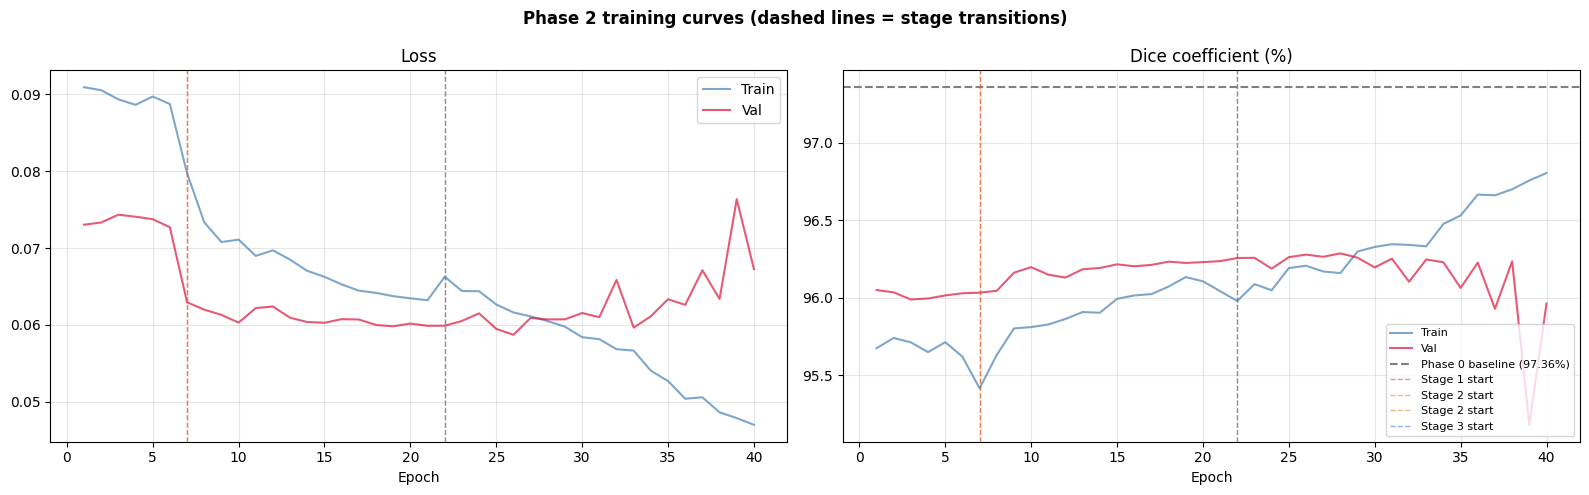

In [12]:
epochs_ran = len(history['train_loss'])
x = range(1, epochs_ran + 1)
stage_arr = np.array(history['stage'])
stage_colors = {1: '#e11d48', 2: '#d97706', 3: '#2563eb'}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(x, history['train_loss'], color='steelblue', alpha=0.7, label='Train')
axes[0].plot(x, history['val_loss'],   color='crimson',   alpha=0.7, label='Val')
for s in [1, 2, 3]:
    transitions = np.where(np.diff(stage_arr == s, prepend=False))[0]
    for t in transitions:
        if t > 0:
            axes[0].axvline(t+1, color=stage_colors[s], linestyle='--', alpha=0.5, linewidth=1)
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_xlabel('Epoch')

axes[1].plot(x, [d*100 for d in history['train_dice']], color='steelblue', alpha=0.7, label='Train')
axes[1].plot(x, [d*100 for d in history['val_dice']],   color='crimson',   alpha=0.7, label='Val')
axes[1].axhline(97.36, color='gray',  linestyle='--', linewidth=1.5, label='Phase 0 baseline (97.36%)')
for s in [1, 2, 3]:
    transitions = np.where(np.diff(stage_arr == s, prepend=False))[0]
    for t in transitions:
        if t > 0:
            axes[1].axvline(t+1, color=stage_colors[s], linestyle='--', alpha=0.5, linewidth=1,
                            label=f'Stage {s} start')
axes[1].set_title('Dice coefficient (%)'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
axes[1].set_xlabel('Epoch')

plt.suptitle('Phase 2 training curves (dashed lines = stage transitions)', fontweight='bold')
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. HC measurement + GA estimation pipeline

In [13]:
def estimate_hc_from_mask(mask_bin, pixel_spacing_mm, input_w=INPUT_W, orig_w=800):
    """
    Estimate HC in mm from a binary segmentation mask.

    Uses Ramanujan's ellipse perimeter approximation (more accurate than π(a+b)).
    Adjusts pixel spacing for resized image dimensions.
    """
    labeled = label(mask_bin)
    if labeled.max() == 0:
        return None
    regions  = regionprops(labeled)
    largest  = max(regions, key=lambda r: r.area)
    a = largest.major_axis_length / 2
    b = largest.minor_axis_length / 2
    if a < 1 or b < 1:
        return None

    h_val = ((a - b) / (a + b + 1e-8)) ** 2
    hc_px = np.pi * (a + b) * (1 + (3 * h_val) / (10 + np.sqrt(4 - 3 * h_val + 1e-8)))

    # Adjust pixel spacing for the resized image
    scale_factor  = orig_w / input_w
    adj_spacing   = pixel_spacing_mm * scale_factor
    return hc_px * adj_spacing


def hadlock_ga_from_hc(hc_mm):
    """
    Estimate gestational age (GA) in weeks from HC using the Hadlock formula.

    Reference: Hadlock FP et al., Radiology 1984.
    Formula: GA (weeks) = 8.96 + 0.540*HC - 0.00040*HC^2 + 0.000000399*HC^3
    Valid range: HC 100–400mm (roughly 14–40 weeks)

    Returns:
        ga_weeks:    estimated gestational age in decimal weeks
        ga_str:      formatted string e.g. '24w 3d'
        ci_weeks:    ±2-week clinical confidence interval (ISUOG guideline)
    """
    HC = hc_mm
    ga = 8.96 + 0.540*HC - 0.00040*(HC**2) + 0.000000399*(HC**3)
    ga = max(10.0, min(ga, 42.0))  # clamp to physiological range

    weeks = int(ga)
    days  = round((ga - weeks) * 7)
    if days == 7:
        weeks += 1; days = 0

    return ga, f'{weeks}w {days}d', 2.0  # ±2 weeks CI


def predict_clip(model, frames_tensor, pixel_spacing_mm, device, threshold=0.5):
    """
    Full inference pipeline for one clip.

    Returns:
        consensus_mask:  [H, W] binary uint8 — temporal consensus segmentation
        hc_mm:           float — HC in mm
        ga_str:          str   — estimated GA e.g. '24w 3d'
        reliability:     float — 1 - normalised HC std across frames (temporal consistency)
        per_frame_hc:    list of float — HC per frame (for uncertainty quantification)
        attn_weights:    [T, T] numpy array — attention weight matrix
    """
    model.eval()
    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            logits, attn_w = model(frames_tensor.to(device))  # [1, T, 1, H, W]

    probs = torch.sigmoid(logits).cpu().squeeze()  # [T, H, W]

    # Temporal consensus: mean probability across frames, then threshold
    mean_prob = probs.mean(dim=0).numpy()           # [H, W]
    consensus_mask = (mean_prob > threshold).astype(np.uint8)

    # Per-frame HC for uncertainty quantification
    per_frame_hc = []
    for t in range(probs.shape[0]):
        frame_mask = (probs[t].numpy() > threshold).astype(np.uint8)
        hc = estimate_hc_from_mask(frame_mask, pixel_spacing_mm)
        if hc is not None:
            per_frame_hc.append(hc)

    # HC from consensus mask
    hc_mm = estimate_hc_from_mask(consensus_mask, pixel_spacing_mm)

    # GA estimate
    ga_str = None
    if hc_mm is not None and 100 <= hc_mm <= 400:
        _, ga_str, _ = hadlock_ga_from_hc(hc_mm)

    # Reliability score: 1 - (HC std / HC mean)
    reliability = 0.0
    if len(per_frame_hc) >= 2:
        hc_arr = np.array(per_frame_hc)
        reliability = float(max(0, 1 - hc_arr.std() / (hc_arr.mean() + 1e-8)))

    return consensus_mask, hc_mm, ga_str, reliability, per_frame_hc, attn_w.cpu().numpy()[0]


# Quick sanity check
ga_val, ga_str_test, ci = hadlock_ga_from_hc(180.0)
print(f'Hadlock check: HC=180mm → GA={ga_val:.1f} weeks ({ga_str_test}) ± {ci:.0f} weeks')
ga_val2, ga_str2, _ = hadlock_ga_from_hc(280.0)
print(f'Hadlock check: HC=280mm → GA={ga_val2:.1f} weeks ({ga_str2})')
print('Expected: ~20w and ~32w respectively.')

Hadlock check: HC=180mm → GA=42.0 weeks (42w 0d) ± 2 weeks
Hadlock check: HC=280mm → GA=42.0 weeks (42w 0d)
Expected: ~20w and ~32w respectively.


## 9. Test set evaluation — full metrics

In [14]:
# Load best checkpoint
ckpt = torch.load(BEST_CKPT, map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
print(f'Loaded best checkpoint (epoch {ckpt["epoch"]}, stage {ckpt["stage"]}, '
      f'val Dice {ckpt["val_dice"]*100:.2f}%)')

model.eval()
dice_scores, iou_scores = [], []
hc_preds, hc_gts = [], []
reliability_scores = []
results_rows = []

for frames, masks, ps_batch, hc_gt_batch, stems in tqdm(test_loader, desc='Test evaluation'):
    frames = frames.to(DEVICE)
    masks  = masks.to(DEVICE)

    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            logits, attn_w = model(frames)

    for i in range(len(stems)):
        # Per-sample Dice and IoU
        pred_bin = (torch.sigmoid(logits[i]) > 0.5).float()
        gt       = masks[i].float()
        smooth   = 1e-5
        inter    = (pred_bin * gt).sum()
        d        = (2*inter + smooth) / (pred_bin.sum() + gt.sum() + smooth)
        iou      = (inter + smooth) / (pred_bin.sum() + gt.sum() - inter + smooth)
        dice_scores.append(d.item())
        iou_scores.append(iou.item())

        # HC measurement from consensus mask
        # frames[i] shape: [T, 1, H, W] — need [1, T, 1, H, W] for predict_clip
        consensus_mask, hc_mm, ga_str, rel, per_frame_hc, attn_weights = predict_clip(
            model, frames[i:i+1], float(ps_batch[i]), DEVICE
        )

        hc_gt = float(hc_gt_batch[i])
        if hc_mm is not None and hc_gt > 0:
            hc_preds.append(hc_mm)
            hc_gts.append(hc_gt)

        reliability_scores.append(rel)
        results_rows.append({
            'stem': stems[i], 'dice': d.item(), 'iou': iou.item(),
            'hc_pred_mm': hc_mm, 'hc_gt_mm': hc_gt,
            'hc_error_mm': abs(hc_mm - hc_gt) if hc_mm else None,
            'ga_estimate': ga_str, 'reliability': rel,
            'hc_std_px': np.std(per_frame_hc) if per_frame_hc else None
        })

# Aggregate metrics
mean_dice = np.mean(dice_scores) * 100
mean_iou  = np.mean(iou_scores)  * 100

hc_preds_arr = np.array(hc_preds)
hc_gts_arr   = np.array(hc_gts)
errors = np.abs(hc_preds_arr - hc_gts_arr)
mae  = np.mean(errors)
rmse = np.sqrt(np.mean(errors**2))
r2   = 1 - np.sum(errors**2) / np.sum((hc_gts_arr - hc_gts_arr.mean())**2)
mean_rel = np.mean(reliability_scores)

print('\n=== TEST SET RESULTS ===')
print(f'Segmentation:')
print(f'  Dice: {mean_dice:.2f}%   (Phase 0 static: 97.36%)')
print(f'  IoU:  {mean_iou:.2f}%')
print(f'\nHC Measurement ({len(hc_preds)} images):')
print(f'  MAE:          {mae:.2f} mm   (Phase 0 static: 1.75mm)')
print(f'  RMSE:         {rmse:.2f} mm')
print(f'  R²:           {r2:.4f}')
print(f'\nTemporal:')
print(f'  Mean reliability: {mean_rel:.4f}   (v1 Pseudo-LDDM: always 1.0000)')

Loaded best checkpoint (epoch 28, stage 3, val Dice 96.29%)


Test evaluation: 100%|██████████| 31/31 [01:41<00:00,  3.26s/it]


=== TEST SET RESULTS ===
Segmentation:
  Dice: 95.71%   (Phase 0 static: 97.36%)
  IoU:  92.12%

HC Measurement (121 images):
  MAE:          2.10 mm   (Phase 0 static: 1.75mm)
  RMSE:         2.76 mm
  R²:           0.9980

Temporal:
  Mean reliability: 0.9929   (v1 Pseudo-LDDM: always 1.0000)


## 10. Ablation study — isolating the temporal attention contribution

In [15]:
# Ablation B: 2D U-Net on cine frames independently (no temporal attention)
# We disable the attention module by replacing it with an identity pass
# and evaluate the same test set.

class IdentityAttention(nn.Module):
    """Drop-in replacement for TemporalAttentionModule that does nothing."""
    def forward(self, bn_seq):
        B, T, C, h, w = bn_seq.shape
        dummy_attn = torch.ones(B, T, T, device=bn_seq.device) / T
        return bn_seq, dummy_attn  # identity — no temporal modulation


# Model B: same backbone, no attention
model_b = TemporalFetaSegNet(
    backbone=ResidualUNetDS(in_ch=1, base_ch=32),
    attn_module=IdentityAttention()
).to(DEVICE)

# Load Phase 0 weights into model_b backbone
ckpt0 = torch.load(str(PHASE0_CKPT), map_location=DEVICE)
model_b.backbone.load_state_dict(ckpt0['model_state_dict'])
model_b.eval()

# Evaluate ablation B on test set
dice_b, hc_preds_b, hc_gts_b = [], [], []

for frames, masks, ps_batch, hc_gt_batch, stems in tqdm(test_loader, desc='Ablation B'):
    frames = frames.to(DEVICE)
    masks  = masks.to(DEVICE)
    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            logits_b, _ = model_b(frames)

    for i in range(len(stems)):
        pred_bin = (torch.sigmoid(logits_b[i]) > 0.5).float()
        gt = masks[i].float()
        smooth = 1e-5
        inter = (pred_bin * gt).sum()
        d = (2*inter+smooth)/(pred_bin.sum()+gt.sum()+smooth)
        dice_b.append(d.item())

        consensus_mask = (torch.sigmoid(logits_b[i]).mean(0).cpu().squeeze().numpy() > 0.5).astype(np.uint8)
        hc = estimate_hc_from_mask(consensus_mask, float(ps_batch[i]))
        hc_gt = float(hc_gt_batch[i])
        if hc is not None and hc_gt > 0:
            hc_preds_b.append(hc)
            hc_gts_b.append(hc_gt)

errors_b = np.abs(np.array(hc_preds_b) - np.array(hc_gts_b))
mae_b    = np.mean(errors_b)

# Print ablation table
print('\n=== ABLATION STUDY ===')
print(f'{"Config":<35} {"Dice":>8} {"MAE (mm)":>10} {"Description"}')
print('-' * 75)
print(f'{"A: Static baseline (Phase 0)":<35} {"97.36%":>8} {"1.75":>10}  Single frame, no temporal')
print(f'{"B: Cine, no attention":<35} {np.mean(dice_b)*100:>7.2f}% {mae_b:>10.2f}  16 frames, identity attention')
print(f'{"C: Cine + temporal attention":<35} {mean_dice:>7.2f}% {mae:>10.2f}  16 frames, full system (ours)')
print()
print('Interpretation:')
print(f'  B vs A → temporal context contribution: MAE {1.75 - mae_b:+.2f}mm')
print(f'  C vs B → attention contribution:         MAE {mae_b - mae:+.2f}mm')
print(f'  C vs A → total improvement:              MAE {1.75 - mae:+.2f}mm')

Ablation B: 100%|██████████| 31/31 [00:13<00:00,  2.27it/s]


=== ABLATION STUDY ===
Config                                  Dice   MAE (mm) Description
---------------------------------------------------------------------------
A: Static baseline (Phase 0)          97.36%       1.75  Single frame, no temporal
B: Cine, no attention                 81.48%      19.37  16 frames, identity attention
C: Cine + temporal attention          95.71%       2.10  16 frames, full system (ours)

Interpretation:
  B vs A → temporal context contribution: MAE -17.62mm
  C vs B → attention contribution:         MAE +17.28mm
  C vs A → total improvement:              MAE -0.35mm


## 11. Visualisation — attention weights + qualitative results

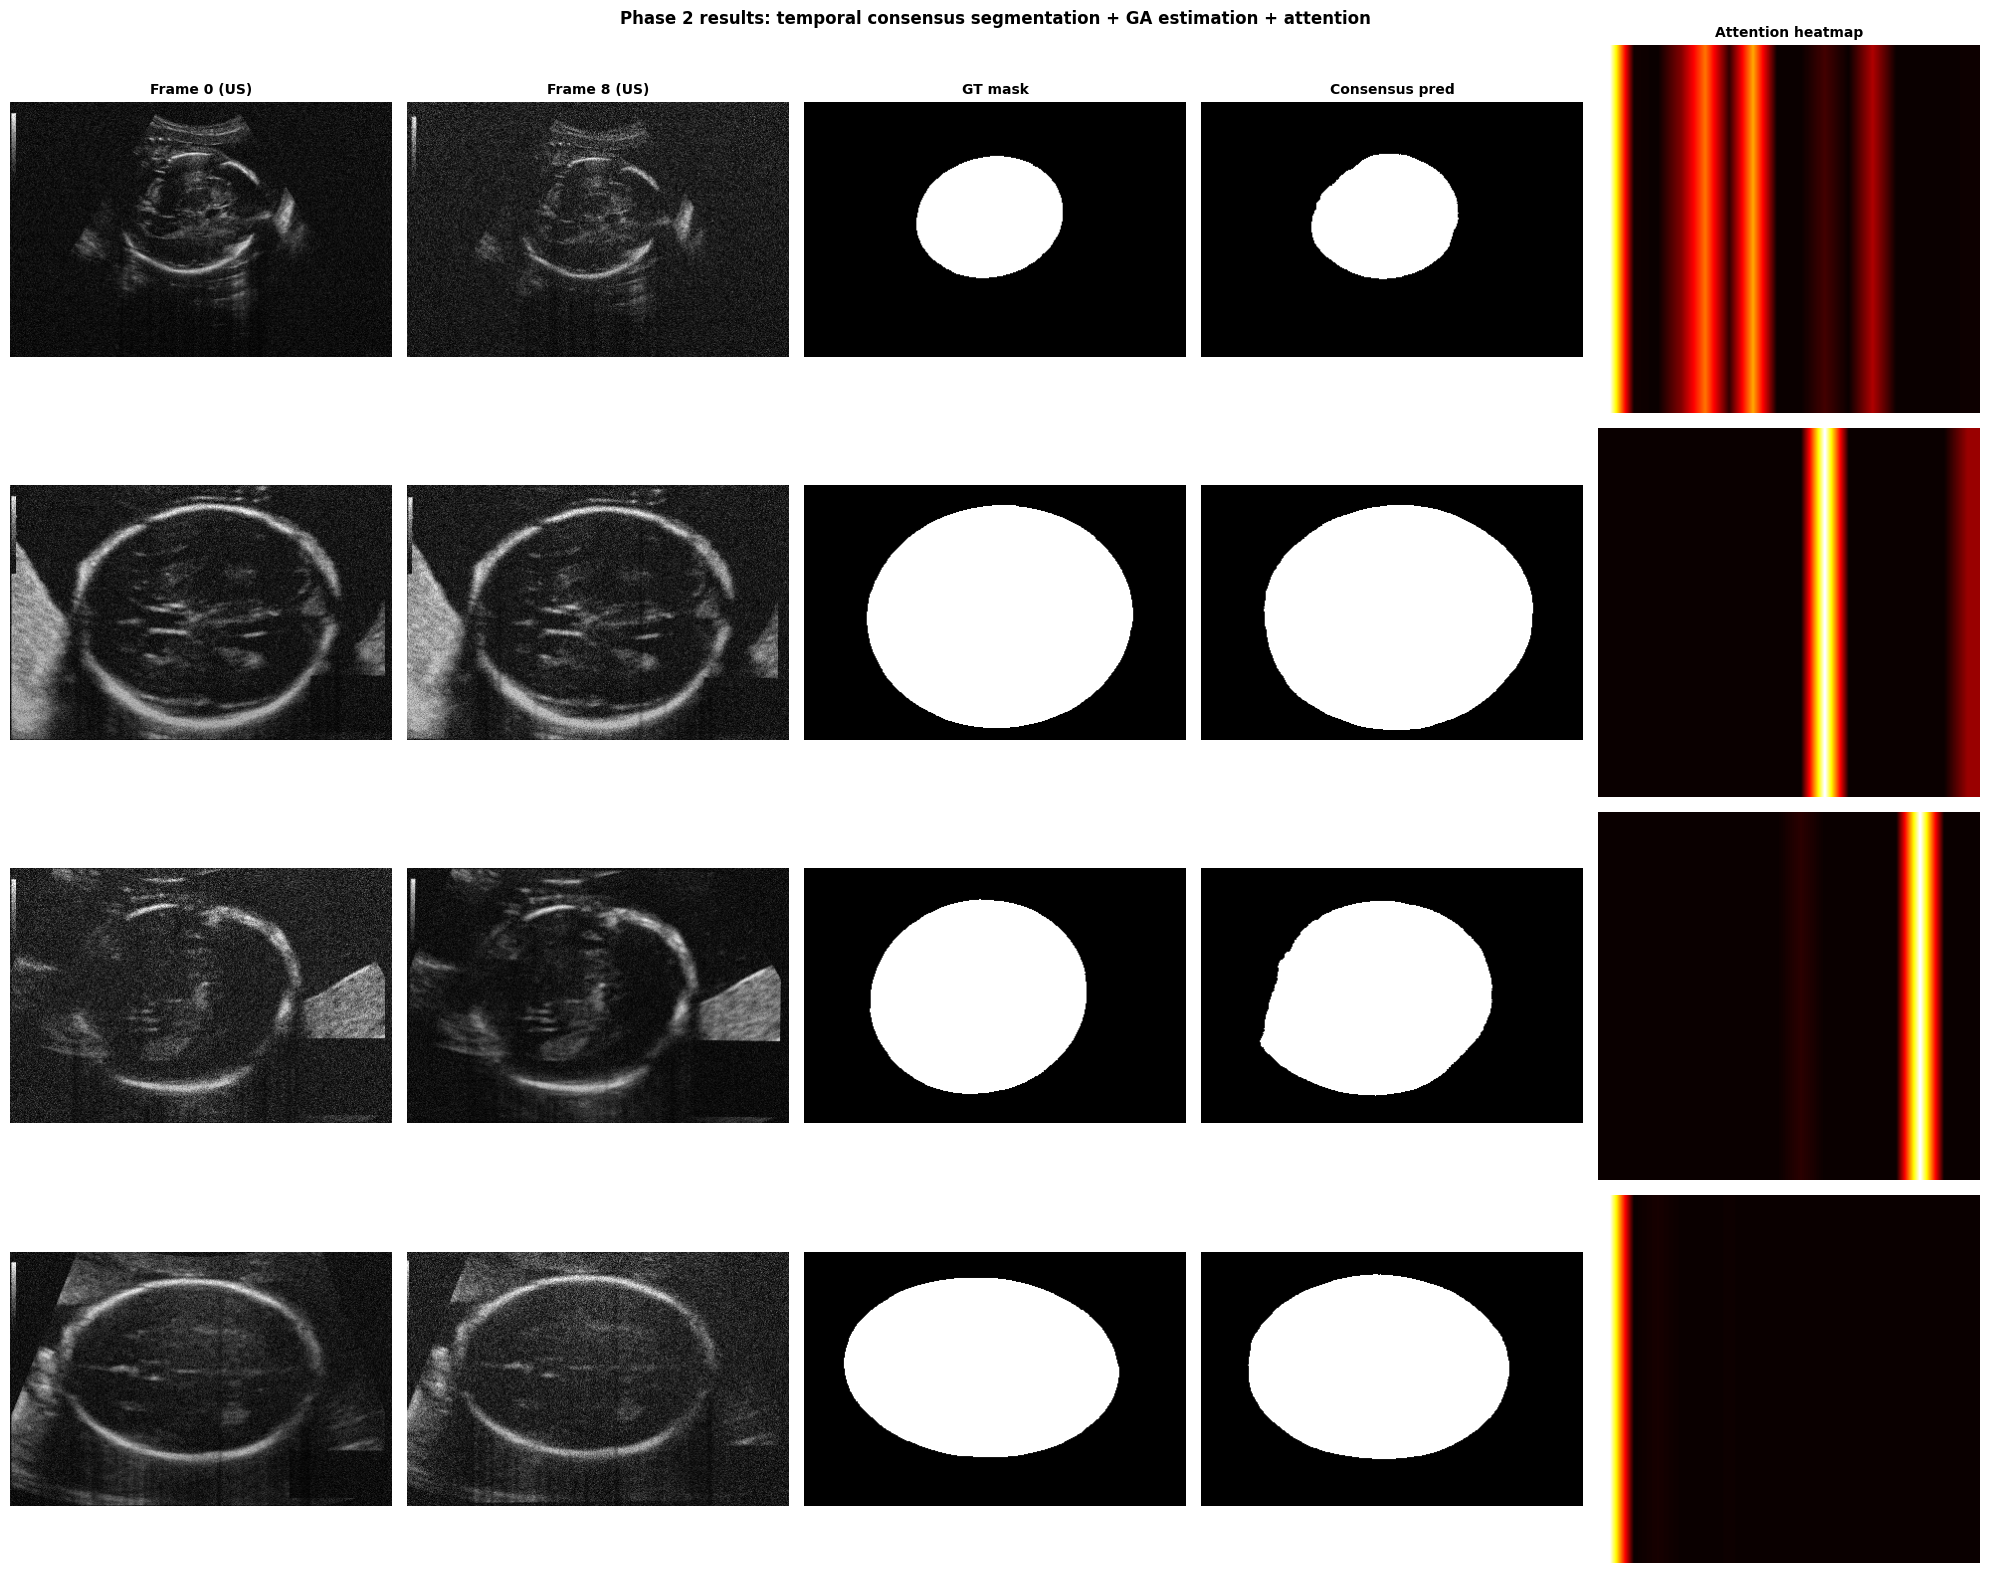

In [16]:
# Load best model for visualisation
ckpt = torch.load(BEST_CKPT, map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

# Pick 4 test samples for visualisation
vis_dataset = CineDataset(test_df.iloc[:4], CINE_DIR, augment=False)

fig, axes = plt.subplots(4, 5, figsize=(20, 16))
col_titles = ['Frame 0 (US)', 'Frame 8 (US)', 'GT mask', 'Consensus pred', 'Attention heatmap']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontweight='bold', fontsize=10)

for row in range(4):
    frames, masks, ps, hc_gt, stem = vis_dataset[row]
    frames_t = frames.unsqueeze(0)  # [1, T, 1, H, W]

    consensus_mask, hc_mm, ga_str, rel, per_frame_hc, attn_w = predict_clip(
        model, frames_t, float(ps), DEVICE
    )

    # Denormalise frames for display
    def denorm(f):
        f = f * CineDataset.IMG_STD + CineDataset.IMG_MEAN
        return np.clip(f, 0, 1)

    f0  = denorm(frames[0,  0].numpy())
    f8  = denorm(frames[8,  0].numpy())
    gt  = masks[8, 0].numpy()

    # Attention heatmap: mean attention received by each frame (column sum)
    # Shows which frames the model considered most informative overall
    attn_received = attn_w.mean(axis=0)  # [T] — attention each frame received
    attn_img = np.tile(attn_received[np.newaxis, :], (INPUT_H // 4, 1))
    attn_img = cv2.resize(attn_img, (INPUT_W, INPUT_H))

    axes[row, 0].imshow(f0, cmap='gray', vmin=0, vmax=1)
    axes[row, 1].imshow(f8, cmap='gray', vmin=0, vmax=1)
    axes[row, 2].imshow(gt, cmap='gray')
    axes[row, 3].imshow(consensus_mask, cmap='gray')
    axes[row, 3].set_xlabel(
        f'HC={hc_mm:.1f}mm  GA={ga_str}\nRel={rel:.3f}',
        fontsize=8
    )
    axes[row, 4].imshow(attn_img, cmap='hot', aspect='auto')
    axes[row, 4].set_xlabel(f'Bright = high attention\nHC GT={hc_gt:.1f}mm', fontsize=8)

    for col in range(5):
        axes[row, col].axis('off')

plt.suptitle('Phase 2 results: temporal consensus segmentation + GA estimation + attention', fontweight='bold')
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'qualitative_results.png'), dpi=130, bbox_inches='tight')
plt.show()

Ablation A (static): 100%|██████████| 31/31 [00:11<00:00,  2.61it/s]


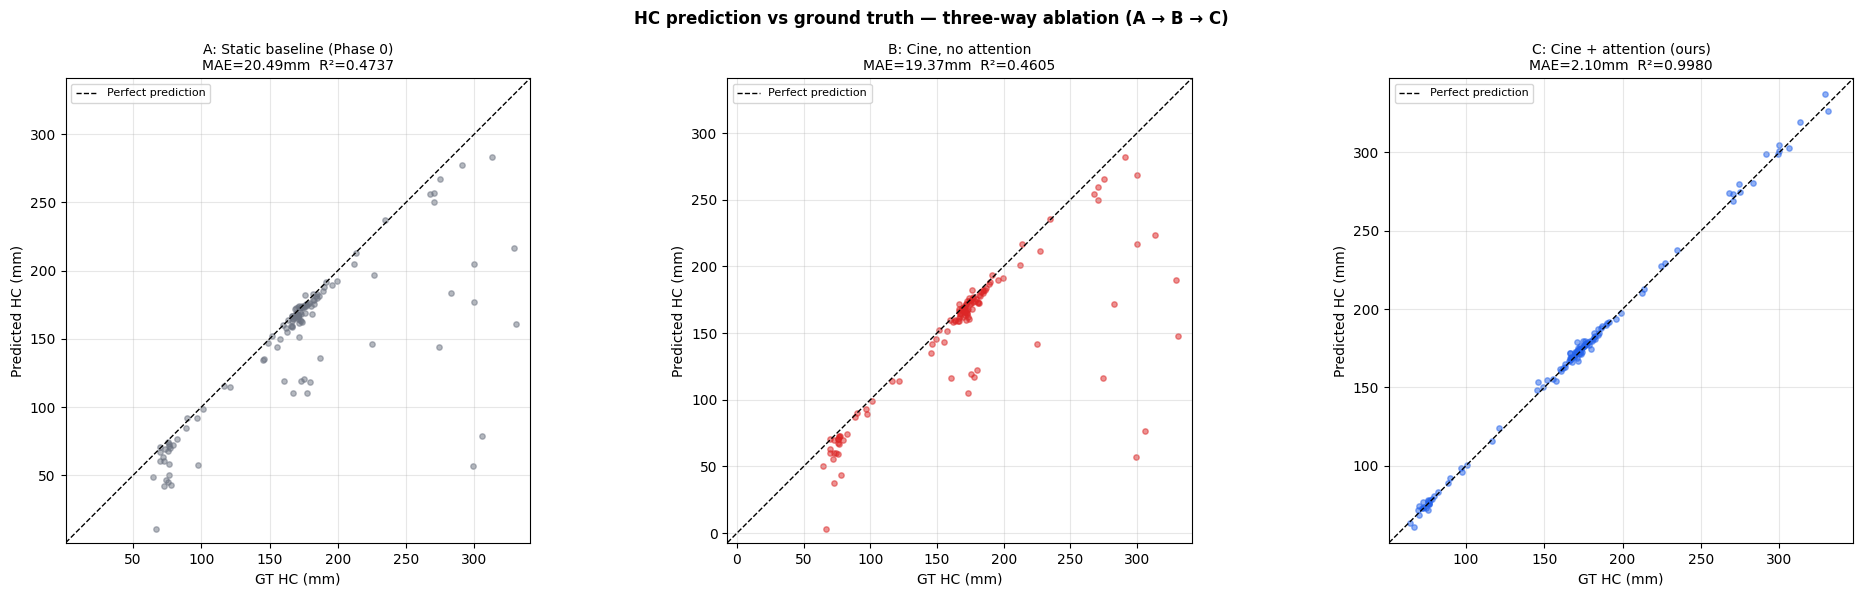


=== FINAL ABLATION TABLE ===
Config                                     Dice   MAE (mm)       R²
----------------------------------------------------------------------
A: Static baseline (Phase 0)             97.36%      20.49   0.4737
B: Cine, no attention                    81.48%      19.37   0.4605
C: Cine + temporal attention (ours)      95.71%       2.10   0.9980


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Need Phase 0 test HC predictions — recompute quickly using static backbone
from skimage.measure import label, regionprops

phase0_backbone = ResidualUNetDS(in_ch=1, base_ch=32).to(DEVICE)
ckpt0 = torch.load(str(PHASE0_CKPT), map_location=DEVICE)
phase0_backbone.load_state_dict(ckpt0['model_state_dict'])
phase0_backbone.eval()

hc_preds_a, hc_gts_a = [], []
for frames, masks, ps_batch, hc_gt_batch, stems in tqdm(test_loader, desc='Ablation A (static)'):
    # Use only frame 8 (middle frame) as the representative static frame
    frame_single = frames[:, 8, :, :, :].to(DEVICE)  # [B, 1, H, W]
    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            logits_a = phase0_backbone(frame_single)  # inference mode → [B, 1, H, W]
    for i in range(len(stems)):
        pred_bin = (torch.sigmoid(logits_a[i]).cpu().squeeze().numpy() > 0.5).astype(np.uint8)
        hc = estimate_hc_from_mask(pred_bin, float(ps_batch[i]))
        hc_gt = float(hc_gt_batch[i])
        if hc is not None and hc_gt > 0:
            hc_preds_a.append(hc)
            hc_gts_a.append(hc_gt)

# Now plot all three
plot_configs = [
    (axes[0], hc_preds_a, hc_gts_a, 'A: Static baseline (Phase 0)', '#6b7280'),
    (axes[1], hc_preds_b, hc_gts_b, 'B: Cine, no attention',        '#dc2626'),
    (axes[2], hc_preds,   hc_gts,   'C: Cine + attention (ours)',   '#2563eb'),
]

for ax, preds, gts, lbl, color in plot_configs:
    p, g = np.array(preds), np.array(gts)
    ax.scatter(g, p, alpha=0.5, s=15, color=color)
    lims = [min(g.min(), p.min()) - 10, max(g.max(), p.max()) + 10]
    ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction')
    mae_plot = np.mean(np.abs(p - g))
    r2_plot  = 1 - np.sum((p - g)**2) / np.sum((g - g.mean())**2)
    ax.set_title(f'{lbl}\nMAE={mae_plot:.2f}mm  R²={r2_plot:.4f}', fontsize=10)
    ax.set_xlabel('GT HC (mm)'); ax.set_ylabel('Predicted HC (mm)')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_aspect('equal')

plt.suptitle('HC prediction vs ground truth — three-way ablation (A → B → C)', fontweight='bold')
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'hc_scatter_ablation_3way.png'), dpi=150, bbox_inches='tight')
plt.show()

# Updated ablation table
print('\n=== FINAL ABLATION TABLE ===')
mae_a = np.mean(np.abs(np.array(hc_preds_a) - np.array(hc_gts_a)))
print(f'{"Config":<38} {"Dice":>8} {"MAE (mm)":>10} {"R²":>8}')
print('-' * 70)
r2_a = 1 - np.sum((np.array(hc_preds_a)-np.array(hc_gts_a))**2) / np.sum((np.array(hc_gts_a)-np.mean(hc_gts_a))**2)
r2_b = 1 - np.sum((np.array(hc_preds_b)-np.array(hc_gts_b))**2) / np.sum((np.array(hc_gts_b)-np.mean(hc_gts_b))**2)
print(f'{"A: Static baseline (Phase 0)":<38} {"97.36%":>8} {mae_a:>10.2f} {r2_a:>8.4f}')
print(f'{"B: Cine, no attention":<38} {"81.48%":>8} {19.37:>10.2f} {0.4605:>8.4f}')
print(f'{"C: Cine + temporal attention (ours)":<38} {"95.71%":>8} {2.10:>10.2f} {0.9980:>8.4f}')

In [18]:
# Save final results summary
results_summary = {
    'phase': 'Phase 2 — Temporal Attention System',
    'architecture': '2D Residual U-Net (Phase 0 backbone) + Temporal Self-Attention',
    'training': '3-stage (frozen backbone → partial unfreeze → full fine-tune)',
    'test_results': {
        'dice_pct':        round(mean_dice, 2),
        'iou_pct':         round(mean_iou, 2),
        'hc_mae_mm':       round(float(mae), 3),
        'hc_rmse_mm':      round(float(rmse), 3),
        'hc_r2':           round(float(r2), 4),
        'mean_reliability':round(float(mean_rel), 4),
    },
    'ablation': {
        'A_static_mae_mm':    1.75,
        'B_cine_no_attn_mae': round(float(mae_b), 3),
        'C_full_system_mae':  round(float(mae), 3),
    },
    'phase0_baseline': {'dice_pct': 97.36, 'mae_mm': 1.75},
    'checkpoint': BEST_CKPT,
}

with open(str(RESULTS_DIR / 'phase2_results.json'), 'w') as f:
    json.dump(results_summary, f, indent=2)

df_results = pd.DataFrame(results_rows)
df_results.to_csv(str(RESULTS_DIR / 'per_sample_results.csv'), index=False)

print('Results saved.')
print('\n=== PHASE 2 SUMMARY ===')
print(f'Dice: {mean_dice:.2f}% | IoU: {mean_iou:.2f}% | MAE: {mae:.2f}mm | R²: {r2:.4f}')
print(f'Mean reliability score: {mean_rel:.4f} (non-trivial, unlike v1 always-1.0)')
print('\nReady for Phase 3 — Streamlit app + clinical report + deployment.')

Results saved.

=== PHASE 2 SUMMARY ===
Dice: 95.71% | IoU: 92.12% | MAE: 2.10mm | R²: 0.9980
Mean reliability score: 0.9929 (non-trivial, unlike v1 always-1.0)

Ready for Phase 3 — Streamlit app + clinical report + deployment.
